<a href="https://colab.research.google.com/github/drlukeweng/NCHU/blob/main/Week4_Model_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 Lab — How Good Is Your AI Doctor?
## 智慧醫療中的醫學影像 | Sensitivity, Specificity, ROC & Optimal Cut-offs

---
**Student Name:** _______________ &nbsp;&nbsp; **Student ID:** _______________ &nbsp;&nbsp; **Date:** _______________

| Exercise | Topic | Points |
|---|---|---|
| 1 | Confusion matrix & all clinical metrics | 20 |
| 2 | ROC curve from scratch + AUC | 20 |
| 3 | Optimal threshold selection | 20 |
| 4 | Probability calibration & ECE | 20 |
| Challenge | Multi-class ROC + subgroup analysis | 20 |
| **Total** | | **100** |

In [ ]:
# ── CELL 0: Setup & Synthetic Dataset ───────────────────────────────────────
import warnings, sys, subprocess
warnings.filterwarnings('ignore')
for pkg in ['scikit-learn','scipy']:
    try: __import__(pkg.replace('-','_').split('.')[0])
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.special import expit as sigmoid  # sigmoid function
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                              average_precision_score, confusion_matrix,
                              cohen_kappa_score)
from sklearn.calibration import CalibrationDisplay, calibration_curve

plt.rcParams.update({'figure.dpi':110,'axes.titlesize':11,'axes.titleweight':'bold'})

# ── Synthetic AI diagnostic dataset ──────────────────────────────────────────
# Scenario: AI model for diabetic retinopathy screening
# y_true: 1=referable DR, 0=no DR
# y_score: AI probability output

N_POS, N_NEG = 300, 700   # 30% prevalence in specialist clinic

# Initialize the random number generator (you can add a seed for reproducibility, e.g., default_rng(42))
rng = np.random.default_rng()
# Now you can use it:
N = N_POS + N_NEG
# Diseased patients: scores from beta(5,2) — skewed toward 1
scores_pos = rng.beta(5, 2, N_POS)
# Healthy patients: scores from beta(2,5) — skewed toward 0
scores_neg = rng.beta(2, 5, N_NEG)

y_score = np.concatenate([scores_pos, scores_neg])
y_true  = np.concatenate([np.ones(N_POS), np.zeros(N_NEG)]).astype(int)

# Shuffle
idx = rng.permutation(N)
y_score, y_true = y_score[idx], y_true[idx]

# Patient metadata for subgroup analysis
age_group = rng.choice(['<50','50-65','>65'], N, p=[0.3,0.4,0.3])
sex       = rng.choice(['Male','Female'], N, p=[0.52,0.48])

# Introduce artificial bias: slightly lower scores for >65 group with disease
mask_bias = (y_true == 1) & (age_group == '>65')
y_score[mask_bias] = np.clip(y_score[mask_bias] - 0.12, 0.05, 0.95)

print(f"✅  Dataset created: N={N} patients")
print(f"   Positive (DR):  {y_true.sum()} ({y_true.mean()*100:.1f}%)")
print(f"   Negative (no DR): {(~y_true.astype(bool)).sum()}")
print(f"   Score range: [{y_score.min():.3f}, {y_score.max():.3f}]")
print(f"   Sklearn AUC (ground truth): {roc_auc_score(y_true, y_score):.4f}")

✅  Dataset created: N=1000 patients
   Positive (DR):  300 (30.0%)
   Negative (no DR): 700
   Score range: [0.002, 0.995]
   Sklearn AUC (ground truth): 0.9459


In [ ]:
# ── CELL 0: Setup & Synthetic Dataset ───────────────────────────────────────
import warnings, sys, subprocess
warnings.filterwarnings('ignore')
for pkg in ['scikit-learn','scipy']:
    try: __import__(pkg.replace('-','_').split('.')[0])
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.special import expit as sigmoid  # sigmoid function
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                              average_precision_score, confusion_matrix,
                              cohen_kappa_score)
from sklearn.calibration import CalibrationDisplay, calibration_curve

plt.rcParams.update({'figure.dpi':110,'axes.titlesize':11,'axes.titleweight':'bold'})
rng = np.random.default_rng(42)

# ── Synthetic AI diagnostic dataset ──────────────────────────────────────────
# Scenario: AI model for diabetic retinopathy screening
# y_true: 1=referable DR, 0=no DR
# y_score: AI probability output

N_POS, N_NEG = 300, 700   # 30% prevalence in specialist clinic
N = N_POS + N_NEG

# Diseased patients: scores from beta(5,2) — skewed toward 1
scores_pos = rng.beta(5, 2, N_POS)
# Healthy patients: scores from beta(2,5) — skewed toward 0
scores_neg = rng.beta(2, 5, N_NEG)

y_score = np.concatenate([scores_pos, scores_neg])
y_true  = np.concatenate([np.ones(N_POS), np.zeros(N_NEG)]).astype(int)

# Shuffle
idx = rng.permutation(N)
y_score, y_true = y_score[idx], y_true[idx]

# Patient metadata for subgroup analysis
age_group = rng.choice(['<50','50-65','>65'], N, p=[0.3,0.4,0.3])
sex       = rng.choice(['Male','Female'], N, p=[0.52,0.48])

# Introduce artificial bias: slightly lower scores for >65 group with disease
mask_bias = (y_true == 1) & (age_group == '>65')
y_score[mask_bias] = np.clip(y_score[mask_bias] - 0.12, 0.05, 0.95)

print(f"✅  Dataset created: N={N} patients")
print(f"   Positive (DR):  {y_true.sum()} ({y_true.mean()*100:.1f}%)")
print(f"   Negative (no DR): {(~y_true.astype(bool)).sum()}")
print(f"   Score range: [{y_score.min():.3f}, {y_score.max():.3f}]")
print(f"   Sklearn AUC (ground truth): {roc_auc_score(y_true, y_score):.4f}")

✅  Dataset created: N=1000 patients
   Positive (DR):  300 (30.0%)
   Negative (no DR): 700
   Score range: [0.006, 0.975]
   Sklearn AUC (ground truth): 0.9430


---
## Exercise 1 — Confusion Matrix & All Clinical Metrics

**Tasks:**
1. Compute confusion matrix at threshold τ = 0.5
2. Calculate all 7 metrics: Sensitivity, Specificity, PPV, NPV, F1, LR+, LR−
3. Demonstrate the **prevalence effect**: recalculate PPV/NPV at 3 different prevalences
4. Interpret the clinical meaning for each metric

  CONFUSION MATRIX  (τ = 0.5)
                        Pred POS   Pred NEG
  Actual POS (DR)         TP=  255    FN=   45
  Actual NEG (no DR)      FP=   72    TN=  628

  Sensitivity (TPR) : 0.8500  — 85.0% of DR patients detected
  Specificity (TNR) : 0.8971  — 89.7% of healthy correctly cleared
  PPV (Precision)   : 0.7798  — 78.0% of positive predictions are correct
  NPV               : 0.9331  — 93.3% of negative predictions are correct
  F1 Score          : 0.8134
  Accuracy          : 0.8830
  LR+               : 8.26  — 8.3× increase in odds if positive
  LR−               : 0.1672  — reduces odds to 16.7% of original if negative

PREVALENCE EFFECT ON PPV (same Sens & Spec, different populations)
     Prevalence       PPV       NPV  Clinical Context
------------------------------------------------------------------------
     0.1%             0.8%    100.0%   Airport kiosk: general public
     3.0%            20.4%     99.5%   Primary care: GP referral
    10.0%            47.9

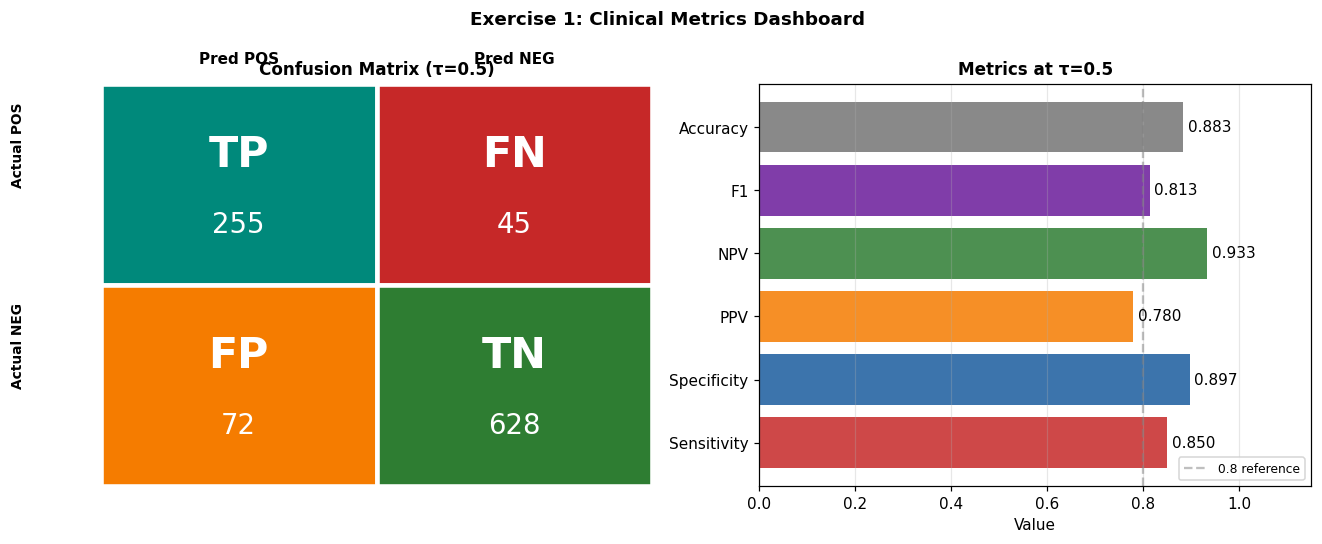

✅  Exercise 1 complete


In [ ]:
# ── EXERCISE 1 ────────────────────────────────────────────────────────────────

def compute_all_metrics(y_true, y_pred, prevalence=None):
    """
    Compute full clinical diagnostic metrics.
    If prevalence is given, recalculate PPV/NPV using Bayes' theorem.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    N = tp + tn + fp + fn

    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    ppv  = tp / (tp + fp + 1e-9)
    npv  = tn / (tn + fn + 1e-9)
    f1   = 2*tp / (2*tp + fp + fn + 1e-9)
    acc  = (tp + tn) / N
    lr_pos = sens / (1 - spec + 1e-9)
    lr_neg = (1 - sens) / (spec + 1e-9)

    if prevalence is not None:
        # Bayes-adjusted PPV and NPV
        ppv = (sens * prevalence) / (sens*prevalence + (1-spec)*(1-prevalence) + 1e-9)
        npv = (spec*(1-prevalence)) / (spec*(1-prevalence) + (1-sens)*prevalence + 1e-9)

    return dict(TP=tp, FP=fp, FN=fn, TN=tn,
                Sensitivity=sens, Specificity=spec,
                PPV=ppv, NPV=npv, F1=f1, Accuracy=acc,
                LR_pos=lr_pos, LR_neg=lr_neg)


# ── 1A: Metrics at τ=0.5 ────────────────────────────────────────────────────
THRESHOLD = 0.5
y_pred = (y_score >= THRESHOLD).astype(int)
m = compute_all_metrics(y_true, y_pred)

print("=" * 55)
print(f"  CONFUSION MATRIX  (τ = {THRESHOLD})")
print("=" * 55)
print(f"  {'':20s}  Pred POS   Pred NEG")
print(f"  {'Actual POS (DR)':22s}  TP={m['TP']:5d}    FN={m['FN']:5d}")
print(f"  {'Actual NEG (no DR)':22s}  FP={m['FP']:5d}    TN={m['TN']:5d}")
print()
print(f"  Sensitivity (TPR) : {m['Sensitivity']:.4f}  — {m['Sensitivity']*100:.1f}% of DR patients detected")
print(f"  Specificity (TNR) : {m['Specificity']:.4f}  — {m['Specificity']*100:.1f}% of healthy correctly cleared")
print(f"  PPV (Precision)   : {m['PPV']:.4f}  — {m['PPV']*100:.1f}% of positive predictions are correct")
print(f"  NPV               : {m['NPV']:.4f}  — {m['NPV']*100:.1f}% of negative predictions are correct")
print(f"  F1 Score          : {m['F1']:.4f}")
print(f"  Accuracy          : {m['Accuracy']:.4f}")
print(f"  LR+               : {m['LR_pos']:.2f}  — {m['LR_pos']:.1f}× increase in odds if positive")
print(f"  LR−               : {m['LR_neg']:.4f}  — reduces odds to {m['LR_neg']*100:.1f}% of original if negative")
print("=" * 55)

# ── 1B: Prevalence Effect ────────────────────────────────────────────────────
print("\nPREVALENCE EFFECT ON PPV (same Sens & Spec, different populations)")
print(f"{'Prevalence':>15}  {'PPV':>8}  {'NPV':>8}  {'Clinical Context'}")
print("-" * 72)
scenarios = [
    (0.001, "Airport kiosk: general public"),
    (0.03,  "Primary care: GP referral"),
    (0.10,  "Optometry clinic: diabetic patients"),
    (0.30,  "Diabetic specialist: high-risk panel"),
    (0.60,  "Retinal clinic: advanced diabetics"),
]
for prev, context in scenarios:
    m2 = compute_all_metrics(y_true, y_pred, prevalence=prev)
    print(f"  {prev*100:>6.1f}%          {m2['PPV']:>7.1%}   {m2['NPV']:>7.1%}   {context}")

# ── 1C: Visual Confusion Matrix ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Exercise 1: Clinical Metrics Dashboard', fontsize=12, fontweight='bold')

cm_vals = np.array([[m['TP'], m['FN']], [m['FP'], m['TN']]])
colors  = [['#00897b','#c62828'],['#f57c00','#2e7d32']]
labels  = [['TP','FN'],['FP','TN']]
ax = axes[0]; ax.set_xlim(0,2); ax.set_ylim(0,2); ax.axis('off')
ax.set_title(f'Confusion Matrix (τ={THRESHOLD})', fontsize=11, fontweight='bold')
for ri in range(2):
    for ci in range(2):
        rect = plt.Rectangle([ci,1-ri],1,1,fc=colors[ri][ci],ec='white',lw=3)
        ax.add_patch(rect)
        ax.text(ci+0.5,1-ri+0.65,labels[ri][ci],ha='center',va='center',
                fontsize=28,fontweight='bold',color='white')
        ax.text(ci+0.5,1-ri+0.3,str(int(cm_vals[ri,ci])),ha='center',va='center',
                fontsize=18,color='white')
ax.text(0.5,2.1,'Pred POS',ha='center',fontsize=10,fontweight='bold')
ax.text(1.5,2.1,'Pred NEG',ha='center',fontsize=10,fontweight='bold')
ax.text(-0.3,1.5,'Actual POS',ha='center',fontsize=9,fontweight='bold',rotation=90)
ax.text(-0.3,0.5,'Actual NEG',ha='center',fontsize=9,fontweight='bold',rotation=90)

# Bar chart of metrics
metric_names = ['Sensitivity','Specificity','PPV','NPV','F1','Accuracy']
metric_vals  = [m[k] for k in metric_names]
colors_bar   = ['#c62828','#1a5c9e','#f57c00','#2e7d32','#6a1b9a','#757575']
axes[1].barh(metric_names, metric_vals, color=colors_bar, alpha=0.85, edgecolor='none')
for i, v in enumerate(metric_vals):
    axes[1].text(v+0.01, i, f'{v:.3f}', va='center', fontsize=10)
axes[1].set_xlim(0, 1.15); axes[1].set_xlabel('Value', fontsize=10)
axes[1].set_title(f'Metrics at τ={THRESHOLD}', fontsize=11, fontweight='bold')
axes[1].axvline(0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 reference')
axes[1].legend(fontsize=8); axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('ex1_metrics.png', dpi=110, bbox_inches='tight')
plt.show()
print("✅  Exercise 1 complete")

### ✏️ Analysis — Exercise 1

**Q1.1** What does the LR+ value tell a clinician who receives a positive AI result? Use your computed LR+ and pre-test probability (30% in our dataset) to compute the post-test probability.

*Your answer:*

**Q1.2** Looking at the prevalence table: if this DR screening AI were deployed at a general optometry practice (prevalence ≈ 10%), what fraction of patients flagged as positive would actually have DR? Is this acceptable?

*Your answer:*

**Q1.3** The accuracy metric gives an optimistic picture compared to F1. Explain why for this dataset (30% DR prevalence).

*Your answer:*

---
## Exercise 2 — ROC Curve from Scratch + AUC

**Tasks:**
1. Build the ROC curve **without sklearn** — just NumPy
2. Compute AUC using the trapezoidal rule
3. Verify against `sklearn.metrics.roc_auc_score` (must agree within ±0.001)
4. Also build the Precision-Recall curve and compare both
5. Visualize both curves side by side

AUC from scratch : 0.942981
AUC from sklearn : 0.942981
Difference       : 0.000000  (✅ PASS)


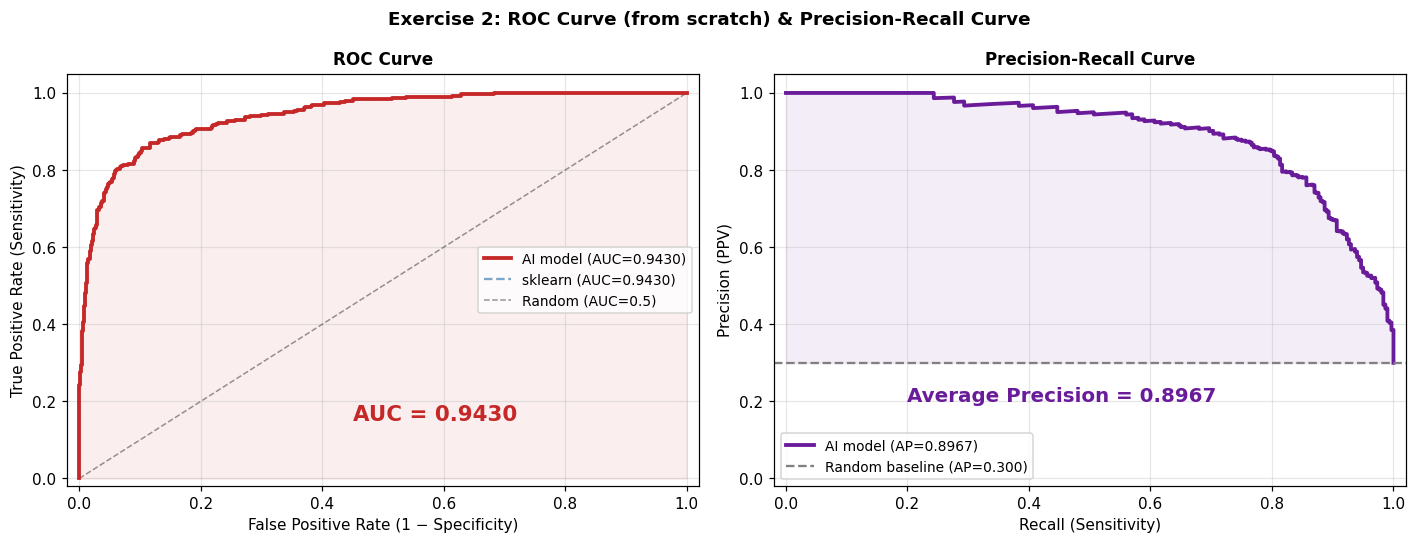

✅  Exercise 2 complete


In [ ]:
# ── EXERCISE 2 ────────────────────────────────────────────────────────────────

def roc_from_scratch(y_true, y_score):
    """
    Build ROC curve without sklearn.
    Returns: fpr_list, tpr_list, thresholds_list
    """
    # Sort by score descending
    sort_idx = np.argsort(y_score)[::-1]
    y_sorted = y_true[sort_idx]
    s_sorted = y_score[sort_idx]

    P = y_true.sum()       # total positives
    N = len(y_true) - P    # total negatives

    fprs = [0.0]
    tprs = [0.0]
    thrs = [s_sorted[0] + 1e-6]  # threshold above first score

    tp, fp = 0, 0
    prev_score = np.inf

    for label, score in zip(y_sorted, s_sorted):
        # When score changes, record current operating point
        if score != prev_score:
            fprs.append(fp / N)
            tprs.append(tp / P)
            thrs.append(score)
            prev_score = score
        if label == 1:
            tp += 1
        else:
            fp += 1

    # Final point (threshold → -∞, everything positive)
    fprs.append(1.0)
    tprs.append(1.0)
    thrs.append(0.0)

    return np.array(fprs), np.array(tprs), np.array(thrs)


def auc_trapezoid(fpr, tpr):
    """AUC by trapezoidal rule."""
    return np.trapz(tpr, fpr)


# ── Compute ROC from scratch ──────────────────────────────────────────────────
fpr_s, tpr_s, thr_s = roc_from_scratch(y_true, y_score)
auc_scratch = auc_trapezoid(fpr_s, tpr_s)

# ── Compute using sklearn ─────────────────────────────────────────────────────
fpr_sk, tpr_sk, thr_sk = roc_curve(y_true, y_score)
auc_sk = roc_auc_score(y_true, y_score)

print(f"AUC from scratch : {auc_scratch:.6f}")
print(f"AUC from sklearn : {auc_sk:.6f}")
print(f"Difference       : {abs(auc_scratch - auc_sk):.6f}  ({'✅ PASS' if abs(auc_scratch-auc_sk)<0.001 else '❌ FAIL'})")

# ── Precision-Recall curve ────────────────────────────────────────────────────
precision, recall, thr_pr = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)
baseline_pr = y_true.mean()  # random classifier PR-AUC

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Exercise 2: ROC Curve (from scratch) & Precision-Recall Curve',
             fontsize=12, fontweight='bold')

# ROC
ax = axes[0]
ax.plot(fpr_s, tpr_s, color='#c62828', lw=2.5, label=f'AI model (AUC={auc_scratch:.4f})', zorder=3)
ax.plot(fpr_sk, tpr_sk, color='steelblue', lw=1.5, linestyle='--',
        alpha=0.7, label=f'sklearn (AUC={auc_sk:.4f})')
ax.plot([0,1],[0,1], 'k--', alpha=0.4, lw=1, label='Random (AUC=0.5)')
ax.fill_between(fpr_s, tpr_s, alpha=0.08, color='#c62828')
ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=10)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=10)
ax.set_title('ROC Curve', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.05)
ax.text(0.45, 0.15, f'AUC = {auc_scratch:.4f}', fontsize=14,
        fontweight='bold', color='#c62828')

# PR
ax2 = axes[1]
ax2.plot(recall, precision, color='#6a1b9a', lw=2.5, label=f'AI model (AP={ap:.4f})')
ax2.axhline(baseline_pr, color='gray', linestyle='--', lw=1.5,
            label=f'Random baseline (AP={baseline_pr:.3f})')
ax2.fill_between(recall, precision, baseline_pr, alpha=0.08, color='#6a1b9a',
                 where=(precision >= baseline_pr))
ax2.set_xlabel('Recall (Sensitivity)', fontsize=10)
ax2.set_ylabel('Precision (PPV)', fontsize=10)
ax2.set_title('Precision-Recall Curve', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.set_xlim(-0.02,1.02); ax2.set_ylim(-0.02,1.05)
ax2.text(0.2, 0.2, f'Average Precision = {ap:.4f}', fontsize=13,
         fontweight='bold', color='#6a1b9a')

plt.tight_layout()
plt.savefig('ex2_roc_pr.png', dpi=110, bbox_inches='tight')
plt.show()
print("✅  Exercise 2 complete")

### ✏️ Analysis — Exercise 2

**Q2.1** Verify your AUC-from-scratch matches sklearn within ±0.001. If it does not, identify and fix the bug in `roc_from_scratch`.

*Your answer:*

**Q2.2** Our dataset has 30% DR prevalence. The PR curve baseline is at 0.30. Comment on the Average Precision score relative to this baseline — what does this tell you about the model's practical clinical utility?

*Your answer:*

**Q2.3** Explain geometrically what the area under the ROC curve represents probabilistically. Use the terms "diseased patient" and "healthy patient" in your answer.

*Your answer:*

---
## Exercise 3 — Optimal Threshold Selection

**Tasks:**
1. Find the Youden's J optimal threshold
2. Apply cost-sensitive optimization with varying C_FN/C_FP ratios
3. Find the threshold that achieves a minimum sensitivity constraint of 90%
4. Compare all three operating points on the ROC curve

Youden's J optimal threshold: 0.4960
  → Sensitivity: 0.8567  Specificity: 0.8971  J=0.7538

Cost-sensitive threshold analysis:
 C_FN/C_FP   Threshold   Sensitivity   Specificity
--------------------------------------------------
         1:1      0.5565        0.8000        0.9400
         2:1      0.4960        0.8567        0.8971
         5:1      0.4233        0.9067        0.8086
        10:1      0.3235        0.9700        0.6171
        20:1      0.2944        0.9833        0.5486

Minimum Sensitivity ≥90% constraint:
  Threshold: 0.4280  Sensitivity: 0.9000  Specificity: 0.8129


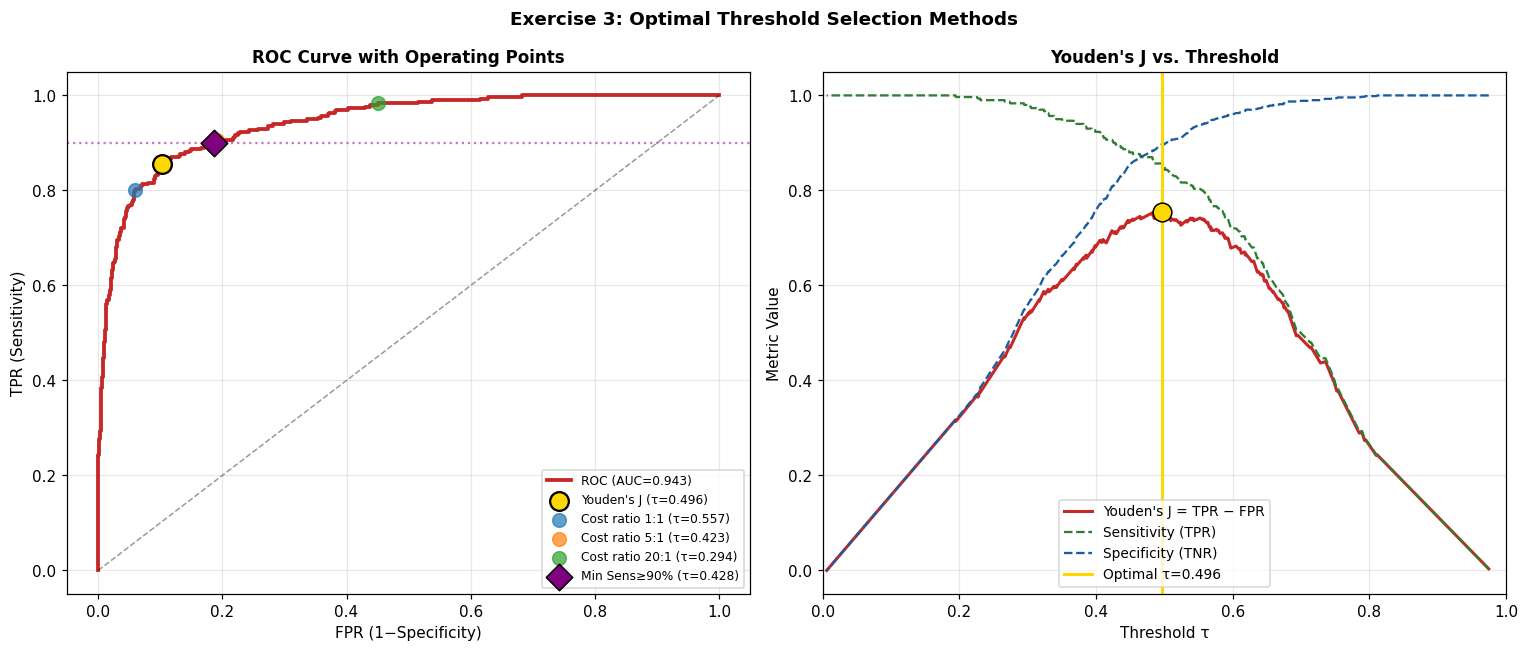

✅  Exercise 3 complete


In [ ]:
# ── EXERCISE 3 ────────────────────────────────────────────────────────────────

# Use sklearn ROC curve (finer resolution)
fpr_vals, tpr_vals, thr_vals = roc_curve(y_true, y_score)

# ── Method 1: Youden's J ─────────────────────────────────────────────────────
J_vals  = tpr_vals - fpr_vals          # J = Sens - (1-Spec) = TPR - FPR
j_idx   = np.argmax(J_vals)
tau_youden = thr_vals[j_idx]
sens_youden = tpr_vals[j_idx]
spec_youden = 1 - fpr_vals[j_idx]

print(f"Youden's J optimal threshold: {tau_youden:.4f}")
print(f"  → Sensitivity: {sens_youden:.4f}  Specificity: {spec_youden:.4f}  J={J_vals[j_idx]:.4f}")

# ── Method 2: Cost-sensitive (vary C_FN/C_FP ratio) ─────────────────────────
print("\nCost-sensitive threshold analysis:")
print(f"{'C_FN/C_FP':>10}  {'Threshold':>10}  {'Sensitivity':>12}  {'Specificity':>12}")
print("-" * 50)

cost_ratios = [1, 2, 5, 10, 20]
cost_results = {}
for ratio in cost_ratios:
    # Compute cost at each threshold
    P = y_true.sum(); Ntotal = len(y_true); Neg = Ntotal - P
    fn_counts = ((1 - tpr_vals) * P)     # FN = (1-TPR) * P
    fp_counts = (fpr_vals * Neg)          # FP = FPR * N
    total_cost = ratio * fn_counts + 1 * fp_counts
    best_idx  = np.argmin(total_cost)
    cost_results[ratio] = {
        'threshold': thr_vals[best_idx],
        'sensitivity': tpr_vals[best_idx],
        'specificity': 1 - fpr_vals[best_idx],
        'fpr': fpr_vals[best_idx],
    }
    print(f"  {ratio:>8}:1  {thr_vals[best_idx]:>10.4f}  {tpr_vals[best_idx]:>12.4f}  {1-fpr_vals[best_idx]:>12.4f}")

# ── Method 3: Minimum Sensitivity Constraint ─────────────────────────────────
MIN_SENS = 0.90
eligible = np.where(tpr_vals >= MIN_SENS)[0]
# Among eligible, pick the one with highest specificity (= lowest FPR)
best_spec_idx = eligible[np.argmin(fpr_vals[eligible])]
tau_constrained = thr_vals[best_spec_idx]
sens_constrained = tpr_vals[best_spec_idx]
spec_constrained = 1 - fpr_vals[best_spec_idx]
print(f"\nMinimum Sensitivity ≥{MIN_SENS:.0%} constraint:")
print(f"  Threshold: {tau_constrained:.4f}  Sensitivity: {sens_constrained:.4f}  Specificity: {spec_constrained:.4f}")

# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Exercise 3: Optimal Threshold Selection Methods',
             fontsize=12, fontweight='bold')

# ROC with operating points
ax = axes[0]
ax.plot(fpr_vals, tpr_vals, color='#c62828', lw=2.5, label=f'ROC (AUC={auc_sk:.3f})')
ax.plot([0,1],[0,1],'k--',alpha=0.4,lw=1)
ax.scatter([fpr_vals[j_idx]], [tpr_vals[j_idx]],
           s=150, color='gold', zorder=5, edgecolors='black', lw=1.5,
           label=f"Youden's J (τ={tau_youden:.3f})")
for ratio, res in cost_results.items():
    if ratio in [1, 5, 20]:
        ax.scatter([res['fpr']], [res['sensitivity']], s=80, alpha=0.7, zorder=5,
                   label=f'Cost ratio {ratio}:1 (τ={res["threshold"]:.3f})')
ax.scatter([fpr_vals[best_spec_idx]], [tpr_vals[best_spec_idx]],
           s=150, color='purple', marker='D', zorder=5, edgecolors='black',
           label=f'Min Sens≥90% (τ={tau_constrained:.3f})')
ax.axhline(MIN_SENS, color='purple', linestyle=':', alpha=0.5)
ax.set_xlabel('FPR (1−Specificity)'); ax.set_ylabel('TPR (Sensitivity)')
ax.set_title('ROC Curve with Operating Points'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Youden's J curve
ax2 = axes[1]
ax2.plot(thr_vals[1:], J_vals[1:], color='#c62828', lw=2, label="Youden's J = TPR − FPR")
ax2.plot(thr_vals[1:], tpr_vals[1:], color='#2e7d32', lw=1.5, linestyle='--', label='Sensitivity (TPR)')
ax2.plot(thr_vals[1:], 1-fpr_vals[1:], color='#1a5c9e', lw=1.5, linestyle='--', label='Specificity (TNR)')
ax2.axvline(tau_youden, color='gold', lw=2, linestyle='-',
            label=f"Optimal τ={tau_youden:.3f}")
ax2.scatter([tau_youden], [J_vals[j_idx]], s=150, color='gold', zorder=5, edgecolors='black')
ax2.set_xlabel('Threshold τ'); ax2.set_ylabel('Metric Value')
ax2.set_title("Youden's J vs. Threshold"); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.set_xlim(0,1); ax2.set_ylim(-0.05,1.05)

plt.tight_layout()
plt.savefig('ex3_threshold.png', dpi=110, bbox_inches='tight')
plt.show()
print("✅  Exercise 3 complete")

### ✏️ Analysis — Exercise 3

**Q3.1** As C_FN/C_FP increases from 1 to 20, how does the optimal threshold change? Explain the clinical rationale (think: what are we optimizing when we weight FN more heavily?).

*Your answer:*

**Q3.2** The minimum-sensitivity-constrained threshold gives Sensitivity ≥ 90%. What is the trade-off (what metric suffers)? In what clinical scenario would a regulatory body impose a minimum sensitivity requirement?

*Your answer:*

**Q3.3** In your Youden's J curve, at what threshold do Sensitivity and Specificity cross? Is this the same as the Youden optimal threshold? Explain why or why not.

*Your answer:*

---
## Exercise 4 — Probability Calibration & ECE

**Tasks:**
1. Compute ECE from scratch
2. Plot the reliability diagram
3. Simulate an overconfident model and compare calibration
4. Apply temperature scaling to improve calibration

Original model ECE      : 0.1729  (17.29%)
Overconfident model ECE : 0.0517  (5.17%)
After temperature (T=1.06) ECE: 0.0538  (5.38%)

AUC preserved? Orig=0.9430  Overconf=0.9430  Calibrated=0.9430
Note: Temperature scaling does NOT change AUC (only monotone transform) ✓


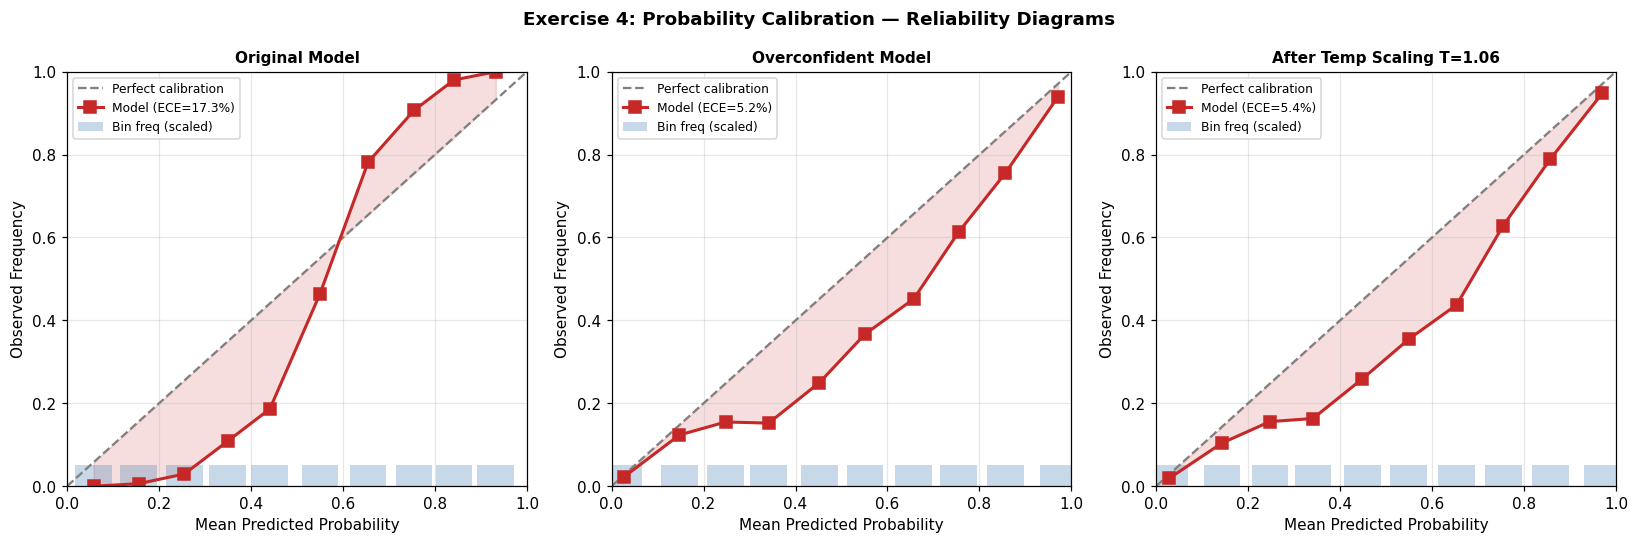

✅  Exercise 4 complete


In [ ]:
# ── EXERCISE 4 ────────────────────────────────────────────────────────────────

from scipy.optimize import minimize_scalar

def compute_ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error — NumPy implementation."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_details = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            bin_details.append({'n':0,'conf':0,'acc':0})
            continue
        conf = y_prob[mask].mean()
        acc  = y_true[mask].mean()
        n    = mask.sum()
        ece += (n / len(y_true)) * abs(conf - acc)
        bin_details.append({'n':n,'conf':conf,'acc':acc})
    return ece, bin_details


def temperature_scaling(y_true, y_score_logits, T_range=(0.1, 10.0)):
    """Find optimal temperature T minimizing NLL on held-out data."""
    def nll(T):
        p = sigmoid(y_score_logits / T)
        return -np.mean(y_true * np.log(p + 1e-9) +
                        (1 - y_true) * np.log(1 - p + 1e-9))
    result = minimize_scalar(nll, bounds=T_range, method='bounded')
    return result.x, sigmoid(y_score_logits / result.x)


# ── Original model: y_score ───────────────────────────────────────────────────
ece_orig, bins_orig = compute_ece(y_true, y_score)

# ── Overconfident model: push scores toward extremes ────────────────────────
def make_overconfident(scores, factor=2.5):
    """Simulate overconfident model by sharpening scores."""
    logits = np.log(scores / (1 - scores + 1e-9))
    return sigmoid(logits * factor)

y_overconf = make_overconfident(y_score, factor=3.0)
ece_overconf, bins_overconf = compute_ece(y_true, y_overconf)

# ── Temperature scaling on overconfident model ───────────────────────────────
logits_overconf = np.log(y_overconf / (1 - y_overconf + 1e-9))
T_opt, y_calibrated = temperature_scaling(y_true, logits_overconf)
ece_calib, bins_calib = compute_ece(y_true, y_calibrated)

print(f"Original model ECE      : {ece_orig:.4f}  ({ece_orig*100:.2f}%)")
print(f"Overconfident model ECE : {ece_overconf:.4f}  ({ece_overconf*100:.2f}%)")
print(f"After temperature (T={T_opt:.2f}) ECE: {ece_calib:.4f}  ({ece_calib*100:.2f}%)")
print(f"\nAUC preserved? Orig={roc_auc_score(y_true,y_score):.4f}  "
      f"Overconf={roc_auc_score(y_true,y_overconf):.4f}  "
      f"Calibrated={roc_auc_score(y_true,y_calibrated):.4f}")
print("Note: Temperature scaling does NOT change AUC (only monotone transform) ✓")

# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Exercise 4: Probability Calibration — Reliability Diagrams',
             fontsize=12, fontweight='bold')

def plot_reliability(ax, y_true, y_prob, title, ece_val):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    ax.plot([0,1],[0,1],'--',color='gray',lw=1.5,label='Perfect calibration')
    ax.plot(prob_pred, prob_true, 's-', color='#c62828', lw=2, ms=8,
            label=f'Model (ECE={ece_val*100:.1f}%)')
    ax.fill_between(prob_pred, prob_true, prob_pred, alpha=0.15, color='#c62828')
    ax.bar(prob_pred, [0.05]*len(prob_pred), width=0.08, alpha=0.3,
           color='steelblue', bottom=0, label='Bin freq (scaled)')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Observed Frequency')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plot_reliability(axes[0], y_true, y_score,      f'Original Model',       ece_orig)
plot_reliability(axes[1], y_true, y_overconf,   f'Overconfident Model',  ece_overconf)
plot_reliability(axes[2], y_true, y_calibrated, f'After Temp Scaling T={T_opt:.2f}', ece_calib)

plt.tight_layout()
plt.savefig('ex4_calibration.png', dpi=110, bbox_inches='tight')
plt.show()
print("✅  Exercise 4 complete")

### ✏️ Analysis — Exercise 4

**Q4.1** After temperature scaling, confirm that the AUC is unchanged. Explain mathematically why temperature scaling (a monotone transformation) cannot change AUC.

*Your answer:*

**Q4.2** Describe the appearance of the overconfident model's reliability diagram. What does it mean clinically when a radiology AI is overconfident?

*Your answer:*

**Q4.3** If the optimal temperature T > 1, what does this tell you about the original model's calibration? What if T < 1?

*Your answer:*

---
## Challenge — Multi-class ROC & Subgroup Fairness Analysis

**Tasks:**
1. Compute one-vs-rest AUC for a 4-class eye disease classification task
2. Perform subgroup analysis by age group: `<50`, `50-65`, `>65`
3. Identify which subgroup the model underperforms on
4. Generate a fairness report

  SUBGROUP FAIRNESS ANALYSIS
  Task: Diabetic Retinopathy Detection

Group              N   Prev%     AUC  Sens@Youden  Spec@Youden
------------------------------------------------------------
  Age <50        313   31.6%  0.9578      0.8687       0.9486
  Age 50-65      410   28.0%  0.9644      0.9217       0.9017
  Age >65        277   31.0%  0.9003      0.8488       0.7801
  Male           535   31.6%  0.9530      0.8994       0.8880
  Female         465   28.2%  0.9296      0.8015       0.9341
  Overall       1000   30.0%  0.9430      0.8567       0.8971

  MULTI-CLASS ROC (One-vs-Rest)
  Macro-average AUC: 1.0000
  Class             N  Prev%   OvR AUC
----------------------------------------
  Normal          388  48.5%    1.0000
  DR-mild         168  21.0%    1.0000
  DR-moderate     153  19.1%    1.0000
  Glaucoma         91  11.4%    1.0000


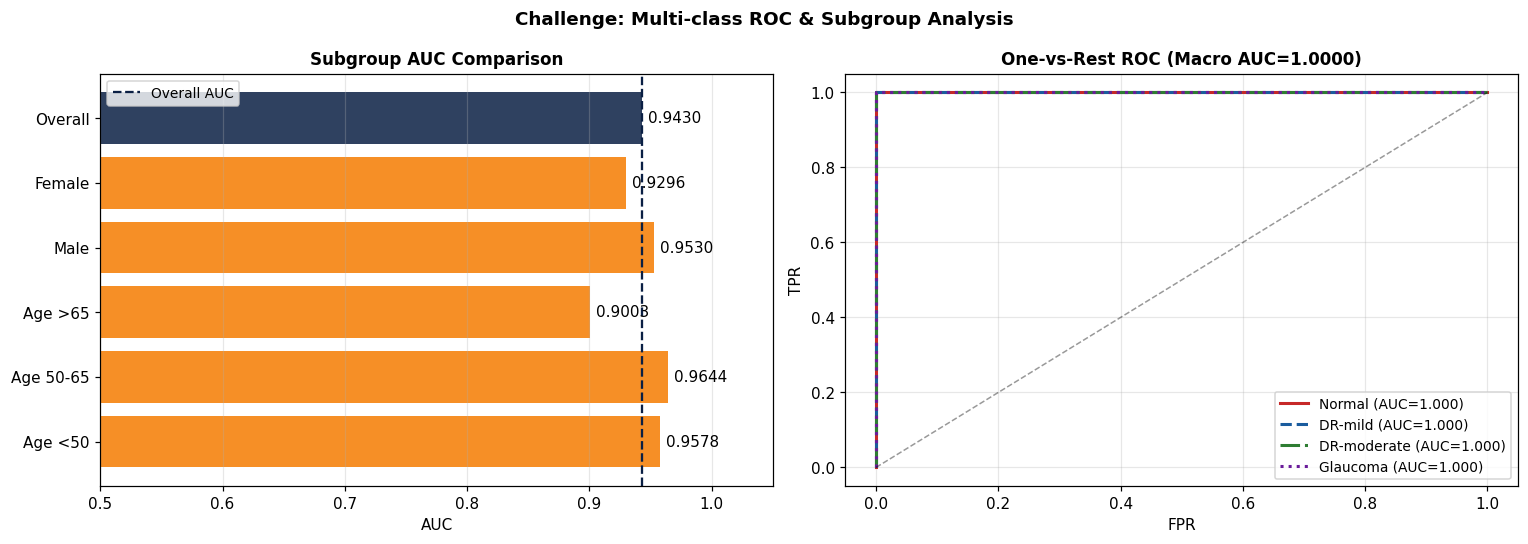


✅  Challenge complete!


In [ ]:
# ── CHALLENGE ─────────────────────────────────────────────────────────────────

from sklearn.metrics import roc_auc_score as sklearn_auc
from sklearn.preprocessing import label_binarize

# ── Subgroup Analysis on Binary Task ─────────────────────────────────────────
print("=" * 65)
print("  SUBGROUP FAIRNESS ANALYSIS")
print("  Task: Diabetic Retinopathy Detection")
print("=" * 65)

groups = {
    'Age <50':    age_group == '<50',
    'Age 50-65':  age_group == '50-65',
    'Age >65':    age_group == '>65',
    'Male':       sex == 'Male',
    'Female':     sex == 'Female',
    'Overall':    np.ones(len(y_true), dtype=bool),
}

print(f"\n{'Group':<14} {'N':>5} {'Prev%':>7} {'AUC':>7} {'Sens@Youden':>12} {'Spec@Youden':>12}")
print("-" * 60)

group_results = {}
for grp_name, mask in groups.items():
    yt_g = y_true[mask]
    ys_g = y_score[mask]
    if yt_g.sum() < 5 or (yt_g==0).sum() < 5:
        print(f"  {grp_name:<12}: insufficient data")
        continue
    auc_g = sklearn_auc(yt_g, ys_g)
    fp_g, tp_g, th_g = roc_curve(yt_g, ys_g)
    J_g   = tp_g - fp_g
    j_g   = np.argmax(J_g)
    group_results[grp_name] = {
        'n': mask.sum(), 'prev': yt_g.mean()*100,
        'auc': auc_g, 'sens': tp_g[j_g], 'spec': 1-fp_g[j_g]
    }
    print(f"  {grp_name:<12} {mask.sum():>5} {yt_g.mean()*100:>6.1f}% {auc_g:>7.4f} "
          f"{tp_g[j_g]:>11.4f}  {1-fp_g[j_g]:>11.4f}")

# ── 4-class Eye Disease Multi-class ROC ──────────────────────────────────────
# Synthetic 4-class scores for: Normal, DR-mild, DR-moderate, Glaucoma
NC = 800
y4_true = rng.choice([0,1,2,3], NC, p=[0.5,0.2,0.2,0.1])
classes = ['Normal','DR-mild','DR-moderate','Glaucoma']
# Simulate 4-class softmax output
y4_score = np.zeros((NC, 4))
for i, lbl in enumerate(y4_true):
    # High prob for correct class with noise
    base = rng.dirichlet(np.ones(4) * 0.5)
    boost = 2.0 + rng.uniform(0, 1)
    base[lbl] += boost
    y4_score[i] = base / base.sum()

# OvR AUC
y4_bin = label_binarize(y4_true, classes=[0,1,2,3])
macro_auc = sklearn_auc(y4_bin, y4_score, multi_class='ovr', average='macro')

print(f"\n{'='*55}")
print("  MULTI-CLASS ROC (One-vs-Rest)")
print(f"  Macro-average AUC: {macro_auc:.4f}")
print(f"  {'Class':<14} {'N':>4} {'Prev%':>6} {'OvR AUC':>9}")
print("-"*40)
for c, cls_name in enumerate(classes):
    auc_c = sklearn_auc(y4_bin[:,c], y4_score[:,c])
    n_c   = (y4_true==c).sum()
    print(f"  {cls_name:<14} {n_c:>4} {n_c/NC*100:>5.1f}% {auc_c:>9.4f}")

# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Challenge: Multi-class ROC & Subgroup Analysis', fontsize=12, fontweight='bold')

# Subgroup AUC bar chart
sg_names = list(group_results.keys())
sg_aucs  = [group_results[g]['auc'] for g in sg_names]
colors_sg = ['#f57c00' if 'Overall' not in g else '#0a1f44' for g in sg_names]
bars = axes[0].barh(sg_names, sg_aucs, color=colors_sg, alpha=0.85, edgecolor='none')
for bar, v in zip(bars, sg_aucs):
    axes[0].text(v+0.005, bar.get_y()+bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=10)
axes[0].set_xlim(0.5, 1.05)
axes[0].axvline(group_results['Overall']['auc'], color='#0a1f44',
                linestyle='--', lw=1.5, label='Overall AUC')
axes[0].set_xlabel('AUC'); axes[0].set_title('Subgroup AUC Comparison')
axes[0].legend(fontsize=9); axes[0].grid(axis='x', alpha=0.3)

# Multi-class OvR ROC curves
line_styles = ['-','--','-.',':']
mc_colors = ['#c62828','#1a5c9e','#2e7d32','#6a1b9a']
for c, (cls_name, ls, col) in enumerate(zip(classes, line_styles, mc_colors)):
    fp_c, tp_c, _ = roc_curve(y4_bin[:,c], y4_score[:,c])
    auc_c = sklearn_auc(y4_bin[:,c], y4_score[:,c])
    axes[1].plot(fp_c, tp_c, lw=2, linestyle=ls, color=col,
                 label=f'{cls_name} (AUC={auc_c:.3f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4,lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'One-vs-Rest ROC (Macro AUC={macro_auc:.4f})')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('challenge_multiclass_fairness.png', dpi=110, bbox_inches='tight')
plt.show()
print("\n✅  Challenge complete!")

### ✏️ Analysis — Challenge

**C.1** Which age subgroup has the lowest AUC? Recall that we introduced a deliberate score penalty for diseased patients in the >65 group. How would you detect this in a real clinical AI evaluation (without knowing the data generation process)?

*Your answer:*

**C.2** In the multi-class setting, which disease class is hardest to detect (lowest AUC)? Propose one clinical reason and one algorithmic reason why this class might be harder.

*Your answer:*

**C.3** A colleague argues: "Our AI has AUC=0.93 overall, so it is fair." Using results from your subgroup analysis, explain why this argument is flawed and propose a fairer summary metric.

*Your answer:*

---
## Submission Checklist
- [ ] All cells run (Kernel → Restart & Run All)
- [ ] Exercise 2 AUC-from-scratch matches sklearn ±0.001
- [ ] All analysis questions answered
- [ ] Saved as `Week4_Notebook_[StudentID].ipynb`

---
*智慧醫療中的醫學影像 | Week 4 Lab Notebook | Spring 2026*